In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
def load_data(dataset_path, img_size=(128, 128)):
    X, y = [], []
    class_names = sorted(os.listdir(dataset_path))
    class_indices = {name: idx for idx, name in enumerate(class_names)}

    for label in class_names:
        class_path = os.path.join(dataset_path, label)
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.png', '.bmp')):
                path = os.path.join(class_path, file)
                img = cv2.imread(path)
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(class_indices[label])

    X = np.array(X, dtype='float32') / 255.0
    y = to_categorical(y)
    return X, y, class_names

In [5]:
dataset_path = "/content/drive/MyDrive/Flying object detection/UAV_Dataset"
X, y, class_names = load_data(dataset_path)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
#Побудова моделі CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 98s 930ms/step - accuracy: 0.4208 - loss: 1.4951 - val_accuracy: 0.6236 - val_loss: 0.8728
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 143s 938ms/step - accuracy: 0.6953 - loss: 0.7833 - val_accuracy: 0.7282 - val_loss: 0.6751
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 95s 932ms/step - accuracy: 0.7830 - loss: 0.5778 - val_accuracy: 0.7884 - val_loss: 0.5850
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 142s 932ms/step - accuracy: 0.8486 - loss: 0.4080 - val_accuracy: 0.7835 - val_loss: 0.5735
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 92s 899ms/step - accuracy: 0.8913 - loss: 0.3158 - val_accuracy: 0.7835 - val_loss: 0.5961
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 95s 932ms/step - accuracy: 0.9078 - loss: 0.2651 - val_accuracy: 0.7995 - val_loss: 0.5376
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 101s 988ms/step - accuracy: 0.9355 - loss: 0.1892 - val_accuracy: 0.8081 - val_loss: 0.5957
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 137s 935ms/step - accuracy: 0.9505 - los

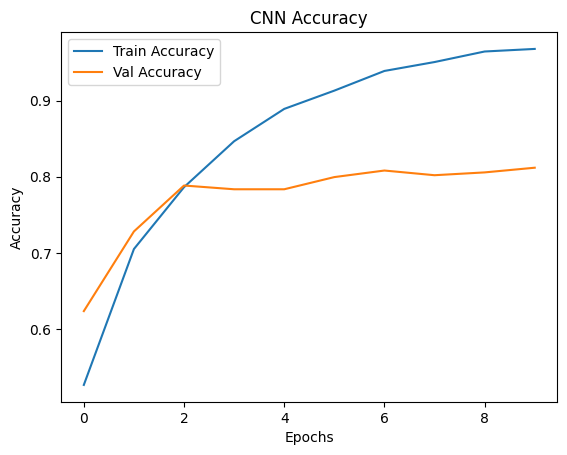

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [16]:
test_path = "/content/drive/MyDrive/Flying object detection/satelite_photos"
test_images = sorted(os.listdir(test_path))

In [17]:
img_size = (128, 128)

In [18]:
class_names = ['Drone', 'Aeroplane', 'Helicopter', 'Bird']

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def preprocess_and_predict(img_path, model, img_size, class_names):
    try:
        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        predictions = model.predict(img_array)
        class_index = np.argmax(predictions)
        class_name = class_names[class_index]
        confidence = float(predictions[0][class_index])

        return class_name, confidence
    except Exception as e:
        print(f"⚠️ Помилка при обробці {img_path}: {e}")
        return None, None


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
📸 1.jpg → Aeroplane (1.00)


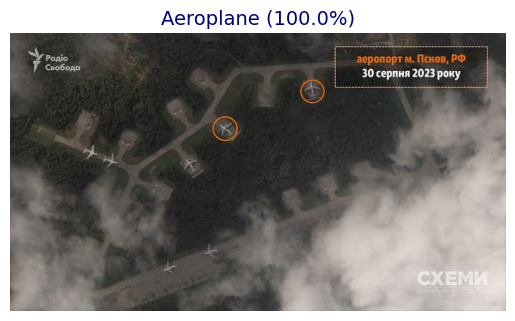

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
📸 2.jpg → Aeroplane (1.00)


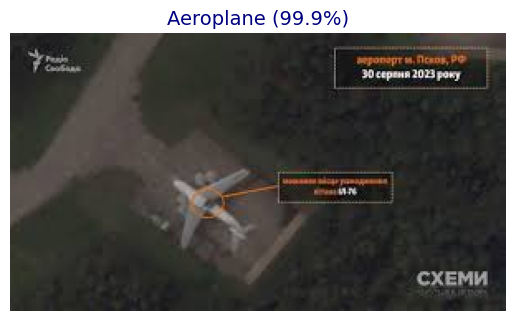

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
📸 3.jpg → Aeroplane (0.94)


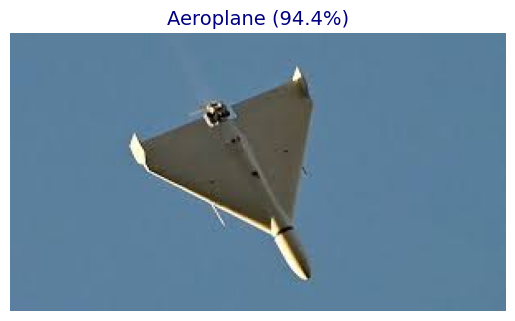

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
📸 4.jpg → Helicopter (0.63)


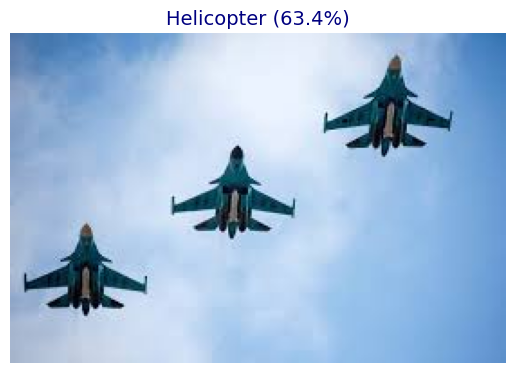

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
📸 5.jpg → Bird (0.88)


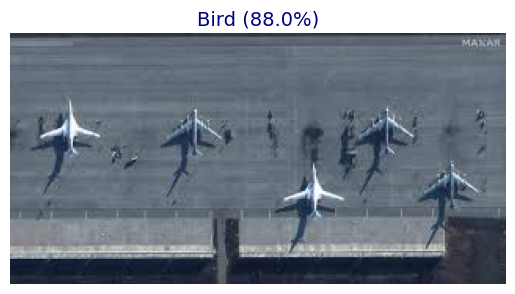

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
📸 6.jpg → Aeroplane (0.98)


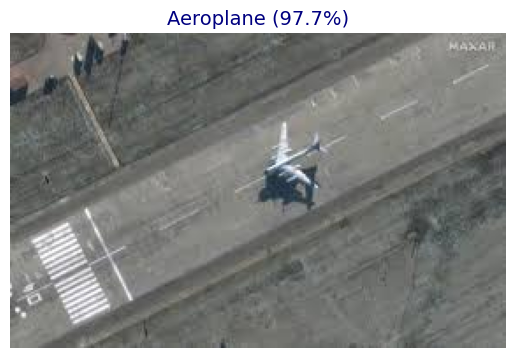

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
📸 7.jpg → Bird (0.92)


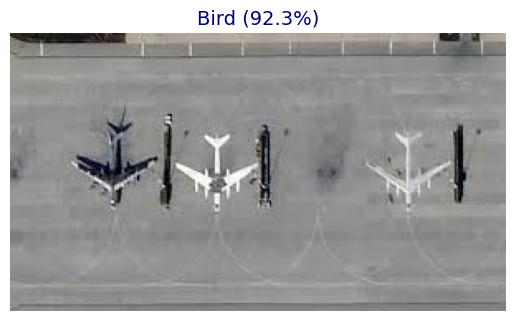

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
📸 8.jpg → Aeroplane (0.49)


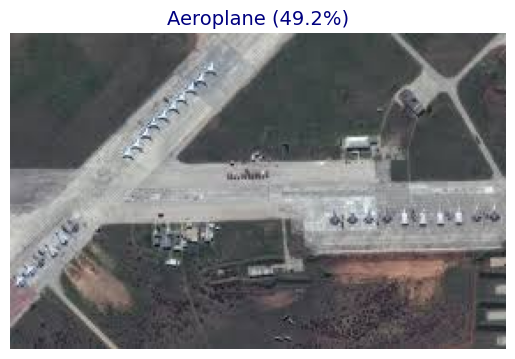


📊 Підсумкові результати:


,Image,Predicted Class,Confidence
0,1.jpg,Aeroplane,0.999975
1,2.jpg,Aeroplane,0.999470
2,3.jpg,Aeroplane,0.944372
3,4.jpg,Helicopter,0.633854
4,5.jpg,Bird,0.879700
5,6.jpg,Aeroplane,0.976914
6,7.jpg,Bird,0.922791
7,8.jpg,Aeroplane,0.491576


In [21]:
import matplotlib.image as mpimg

def show_prediction(img_path, label, confidence):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label} ({confidence*100:.1f}%)", fontsize=14, color='navy')
    plt.show()

# ==== Аналіз усіх зображень ====
results = []

for img_file in test_images:
    img_path = os.path.join(test_path, img_file)
    label, conf = preprocess_and_predict(img_path, model, img_size, class_names)

    if label is not None:
        print(f"📸 {img_file} → {label} ({conf:.2f})")
        show_prediction(img_path, label, conf)
        results.append((img_file, label, conf))
    else:
        print(f"❌ Не вдалося обробити: {img_file}")

# ==== Підсумкова таблиця ====
import pandas as pd

df = pd.DataFrame(results, columns=['Image', 'Predicted Class', 'Confidence'])
print("\n📊 Підсумкові результати:")
display(df)